# Image classification using ANN
 **Performed by:** <br>
 Name: Giridhar Sreekumar <br>
 Date: 20 January 2026

In [6]:
##Required libraries are imported
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


In [9]:
## Loading the dataset
(X_train,y_train),(X_test,y_test)=mnist.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


***Reasoning*** : mnist dataset is built in such a way the data is already split into training and test and we don't require to explicitly split it again. Hence, all we do allocate resources i.e, make variables to store thse data.

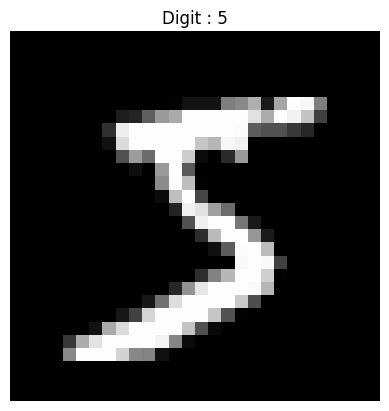

In [10]:
## Visualise sample image

plt.imshow(X_train[0],cmap='grey')
plt.title(f"Digit : {y_train[0]}")
plt.axis("off")
plt.show()

## Preprocessing

Unlike traditional tabular datasets, image datasets do not require extensive feature analysis, encoding, or variable transformation.
The MNIST dataset already consists of clean numerical pixel values, so preprocessing mainly focuses on preparing the image data for neural network input.

The preprocessing steps include reshaping the 2D image matrices into 1D vectors, normalizing pixel intensity values to a common range, and encoding class labels into a suitable format for multi-class classification.
These steps ensure compatibility with Artificial Neural Networks and enable efficient model training.

In [12]:
### Flatten images(ANN needs 1D input)
X_train=X_train.reshape(60000,28*28)
X_test= X_test.reshape(10000, 28*28)


### Normalizing(pixel values from 0->255 to 0->1)
X_train=X_train/255.0
X_test = X_test/255.0

### One-hot encoding
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [14]:
### ================================ MODEL BUILD AND COMPILATION =============================================

model=Sequential([
    Dense(128,activation ='relu', input_shape=(784,)),
    Dense(64, activation = 'relu'),
    Dense(10, activation='softmax') ##Gives 10 output classes
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
##Compile the made model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


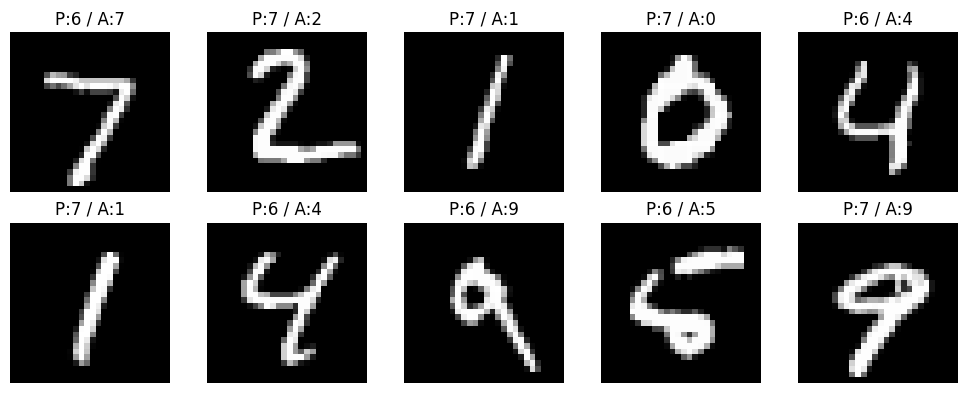

In [19]:
### ============================= PREDICTIONS AND VISUALISATION ===============================================
predictions=model.predict(X_test)

plt.figure(figsize=(10,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_test[i].reshape(28,28),cmap='gray')
  plt.title(f"P:{np.argmax(predictions[i])} / A:{np.argmax(y_test[i])}")
  plt.axis('off')


plt.tight_layout()
plt.show()